# Задание 3

Реализован Adam. Он хранит экспоненциальные средние градиента и его квадрата:

$$m_t = \beta_1 m_{t-1} + (1-\beta_1)g_t, \qquad v_t = \beta_2 v_{t-1} + (1-\beta_2)g_t^2.$$

Поправка на нулевую инициализацию: $\hat m_t = m_t/(1-\beta_1^t)$, $\hat v_t = v_t/(1-\beta_2^t)$.

$$\theta_t = \theta_{t-1} - \eta\frac{\hat m_t}{\sqrt{\hat v_t}+\varepsilon}.$$

Первый момент сглаживает направление, второй задаёт отдельный масштаб шага для каждой координаты. Реализация использует операции torch; обновление параметров выполняется без построения графа.

Источники: [статья Adam](https://arxiv.org/abs/1412.6980), [документация PyTorch](https://docs.pytorch.org/docs/stable/generated/torch.optim.Adam.html).


In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torchvision.datasets import FashionMNIST
import matplotlib.pyplot as plt
import unittest

In [2]:
class Adam:
    def __init__(self, parameters, lr=0.001, betas=(0.9, 0.999), eps=1e-8):
        self.parameters = list(parameters)
        self.lr = lr
        self.betas = betas
        self.eps = eps
        self.m = [torch.zeros_like(p) for p in self.parameters]
        self.v = [torch.zeros_like(p) for p in self.parameters]
        self.steps = [0] * len(self.parameters)

    def zero_grad(self):
        for p in self.parameters:
            p.grad = None

    @torch.no_grad()
    def step(self):
        beta1, beta2 = self.betas
        for i, p in enumerate(self.parameters):
            if p.grad is None:
                continue
            self.steps[i] += 1
            self.m[i] = beta1 * self.m[i] + (1 - beta1) * p.grad
            self.v[i] = beta2 * self.v[i] + (1 - beta2) * p.grad.square()
            m_hat = self.m[i] / (1 - beta1 ** self.steps[i])
            v_hat = self.v[i] / (1 - beta2 ** self.steps[i])
            p -= self.lr * m_hat / (v_hat.sqrt() + self.eps)

## Тесты

Проверяются первые шаги вручную, epsilon, очистка градиентов, пропуск параметров без градиента, отдельный счётчик шагов для каждого параметра и сходимость на квадратичной функции. На нескольких шагах параметры и моменты сравниваются с torch.optim.Adam.


In [3]:
class TestAdam(unittest.TestCase):
    def test_first_step(self):
        p = torch.tensor([1.0, -2.0, 3.0], dtype=torch.float64, requires_grad=True)
        p.grad = torch.tensor([2.0, -4.0, 0.0], dtype=torch.float64)
        optimizer = Adam([p], lr=0.1)
        optimizer.step()
        expected = torch.tensor([0.9, -1.9, 3.0], dtype=torch.float64)
        torch.testing.assert_close(p, expected, rtol=0, atol=1e-9)

    def test_two_steps(self):
        p = torch.tensor(1.0, dtype=torch.float64, requires_grad=True)
        optimizer = Adam([p], lr=0.1, eps=0)
        for _ in range(2):
            p.grad = torch.tensor(2.0, dtype=torch.float64)
            optimizer.step()
        self.assertAlmostEqual(p.item(), 0.8)
        self.assertAlmostEqual(optimizer.m[0].item(), 0.38)
        self.assertAlmostEqual(optimizer.v[0].item(), 0.007996)
        self.assertEqual(optimizer.steps[0], 2)

    def test_epsilon(self):
        p = torch.tensor(1.0, dtype=torch.float64, requires_grad=True)
        p.grad = torch.tensor(2.0, dtype=torch.float64)
        optimizer = Adam([p], lr=0.1, eps=1)
        optimizer.step()
        self.assertAlmostEqual(p.item(), 1 - 0.1 * 2 / 3)

    def test_zero_grad(self):
        p = torch.tensor([1.0, 2.0], requires_grad=True)
        p.grad = torch.ones_like(p)
        optimizer = Adam([p])
        optimizer.zero_grad()
        self.assertIsNone(p.grad)

    def test_no_gradient(self):
        p = torch.tensor(2.0, requires_grad=True)
        optimizer = Adam([p])
        optimizer.step()
        self.assertEqual(p.item(), 2)
        self.assertEqual(optimizer.steps[0], 0)
        self.assertEqual(optimizer.m[0].item(), 0)
        self.assertEqual(optimizer.v[0].item(), 0)

    def test_matches_torch(self):
        p = torch.tensor([[1.0, -2.0], [0.5, 3.0]], dtype=torch.float64, requires_grad=True)
        reference = p.detach().clone().requires_grad_()
        optimizer = Adam([p], lr=0.02, betas=(0.7, 0.8), eps=1e-4)
        expected = torch.optim.Adam([reference], lr=0.02, betas=(0.7, 0.8), eps=1e-4, foreach=False)
        for values in [[0.2, -0.8, 1e-9, 0], [0, 1, -0.7, 0.3], [-0.7, 0.3, 0.5, 0], [0.5, 0, -0.1, -2]]:
            gradient = torch.tensor(values, dtype=torch.float64).view(2, 2)
            p.grad = gradient.clone()
            reference.grad = gradient.clone()
            optimizer.step()
            expected.step()
            torch.testing.assert_close(p, reference, rtol=1e-12, atol=1e-12)
            torch.testing.assert_close(optimizer.m[0], expected.state[reference]["exp_avg"], rtol=1e-12, atol=1e-12)
            torch.testing.assert_close(optimizer.v[0], expected.state[reference]["exp_avg_sq"], rtol=1e-12, atol=1e-12)

    def test_separate_step_counters(self):
        p = torch.tensor(1.0, dtype=torch.float64, requires_grad=True)
        q = torch.tensor(-2.0, dtype=torch.float64, requires_grad=True)
        references = [value.detach().clone().requires_grad_() for value in [p, q]]
        optimizer = Adam([p, q], lr=0.1)
        expected = torch.optim.Adam(references, lr=0.1, foreach=False)
        for gradients in [(2.0, None), (None, -3.0), (1.0, 0.5)]:
            optimizer.zero_grad()
            expected.zero_grad()
            for value, reference, gradient in zip([p, q], references, gradients):
                if gradient is not None:
                    value.grad = torch.tensor(gradient, dtype=torch.float64)
                    reference.grad = value.grad.clone()
            optimizer.step()
            expected.step()
            for value, reference in zip([p, q], references):
                torch.testing.assert_close(value, reference, rtol=1e-12, atol=1e-12)
        self.assertEqual(optimizer.steps, [2, 2])

    def test_quadratic_convergence(self):
        p = torch.tensor(10.0, dtype=torch.float64, requires_grad=True)
        optimizer = Adam([p], lr=0.1)
        for _ in range(400):
            optimizer.zero_grad()
            loss = (p - 3).square()
            loss.backward()
            optimizer.step()
        self.assertLess((p - 3).square().item(), 1e-8)

In [4]:
suite = unittest.defaultTestLoader.loadTestsFromTestCase(TestAdam)
result = unittest.TextTestRunner(verbosity=2).run(suite)

test_epsilon (__main__.TestAdam.test_epsilon) ... 

ok


test_first_step (__main__.TestAdam.test_first_step) ... 

ok


test_matches_torch (__main__.TestAdam.test_matches_torch) ... 

...

test_two_steps (__main__.TestAdam.test_two_steps) ... 

ok


test_zero_grad (__main__.TestAdam.test_zero_grad) ... 

ok


----------------------------------------------------------------------
Ran 8 tests in 0.041s

OK


## FashionMNIST

Используется BaseNetwork из первого задания: 784 → 512 → 256 → 256 → 128 → 10, ReLU, Kaiming для скрытых слоёв и gain = 1 для выходного слоя.
Все 60 000 обучающих и 10 000 тестовых изображений нормализуются по статистикам обучающей выборки.

Сравниваются SGD (lr = 0.01, без momentum) и собственный Adam (lr = 0.001, betas = (0.9, 0.999), eps = 1e-8). Начальные веса и порядок батчей одинаковы, batch size = 256, 8 эпох.
Норма градиента — L2-норма по всем параметрам перед обновлением, усреднённая по батчам эпохи. Распределения весов сохраняются после каждой эпохи.


In [5]:
FashionMNIST.mirrors = ["https://raw.githubusercontent.com/zalandoresearch/fashion-mnist/master/data/fashion/"]
train_data = FashionMNIST("data", train=True, download=True)
test_data = FashionMNIST("data", train=False, download=True)

x_train = train_data.data.float().unsqueeze(1) / 255
x_test = test_data.data.float().unsqueeze(1) / 255
mean, std = x_train.mean(), x_train.std()
x_train = (x_train - mean) / std
x_test = (x_test - mean) / std

train_loader = DataLoader(TensorDataset(x_train, train_data.targets), batch_size=256, shuffle=True)
test_loader = DataLoader(TensorDataset(x_test, test_data.targets), batch_size=256)

In [6]:
class BaseNetwork(nn.Module):
    def __init__(self, act_fn, input_size=784, num_classes=10, hidden_sizes=[512, 256, 256, 128]):
        super().__init__()
        layers = []
        sizes = [input_size] + hidden_sizes
        for i in range(1, len(sizes)):
            layers += [nn.Linear(sizes[i - 1], sizes[i]), act_fn]
        layers += [nn.Linear(sizes[-1], num_classes)]
        self.layers = nn.ModuleList(layers)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        for layer in self.layers:
            x = layer(x)
        return x


def make_model():
    torch.manual_seed(42)
    model = BaseNetwork(nn.ReLU())
    for i, layer in enumerate(model.layers):
        if isinstance(layer, nn.Linear):
            nonlinearity = "relu" if i < len(model.layers) - 1 else "linear"
            nn.init.kaiming_normal_(layer.weight, nonlinearity=nonlinearity)
            nn.init.zeros_(layer.bias)
    return model


def get_weights(model):
    return [layer.weight.detach().flatten().clone() for layer in model.layers if isinstance(layer, nn.Linear)]

In [7]:
def train_model(model, optimizer, epochs=8):
    criterion = nn.CrossEntropyLoss()
    history = {"train_loss": [], "test_loss": [], "test_accuracy": [], "grad_norm": [], "weights": [get_weights(model)]}

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        grad_norm = 0
        for x, y in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            grad_norm += sum(p.grad.square().sum() for p in model.parameters()).sqrt().item()
            optimizer.step()
            train_loss += loss.item() * len(y)

        model.eval()
        test_loss = 0
        correct = 0
        with torch.no_grad():
            for x, y in test_loader:
                logits = model(x)
                test_loss += criterion(logits, y).item() * len(y)
                correct += (logits.argmax(dim=1) == y).sum().item()

        history["train_loss"].append(train_loss / len(train_loader.dataset))
        history["test_loss"].append(test_loss / len(test_loader.dataset))
        history["test_accuracy"].append(correct / len(test_loader.dataset))
        history["grad_norm"].append(grad_norm / len(train_loader))
        history["weights"].append(get_weights(model))
        print(f"epoch={epoch + 1} train_loss={history['train_loss'][-1]:.4f} test_loss={history['test_loss'][-1]:.4f} accuracy={history['test_accuracy'][-1]:.4f} grad_norm={history['grad_norm'][-1]:.4f}")
    return history

In [8]:
optimizers = {
    "SGD": lambda parameters: torch.optim.SGD(parameters, lr=0.01),
    "Adam": lambda parameters: Adam(parameters, lr=0.001)
}

histories = {}
for name, make_optimizer in optimizers.items():
    model = make_model()
    optimizer = make_optimizer(model.parameters())
    torch.manual_seed(123)
    print(name)
    histories[name] = train_model(model, optimizer)

SGD


epoch=1 train_loss=0.7871 test_loss=0.5562 accuracy=0.8030 grad_norm=2.3205


epoch=2 train_loss=0.4968 test_loss=0.4942 accuracy=0.8226 grad_norm=2.3705


epoch=3 train_loss=0.4449 test_loss=0.4606 accuracy=0.8349 grad_norm=2.4314


epoch=4 train_loss=0.4126 test_loss=0.5079 accuracy=0.8203 grad_norm=2.3249


...

epoch=4 train_loss=0.2758 test_loss=0.3439 accuracy=0.8721 grad_norm=1.0812


epoch=5 train_loss=0.2578 test_loss=0.3697 accuracy=0.8692 grad_norm=1.0254


epoch=6 train_loss=0.2393 test_loss=0.3422 accuracy=0.8791 grad_norm=0.9924


epoch=7 train_loss=0.2261 test_loss=0.3294 accuracy=0.8873 grad_norm=0.9549


epoch=8 train_loss=0.2119 test_loss=0.3255 accuracy=0.8849 grad_norm=0.9198


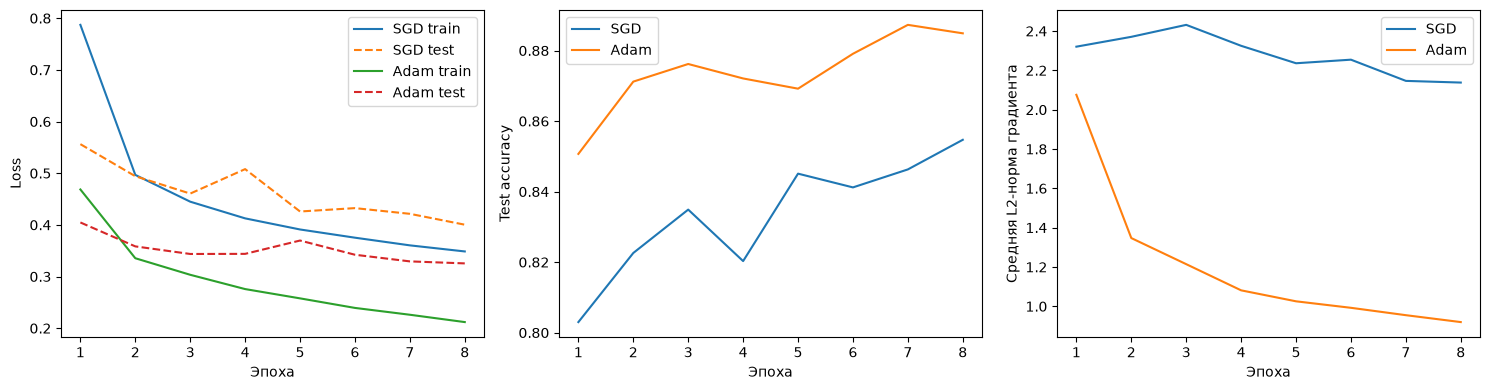

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for name, history in histories.items():
    epochs = range(1, 9)
    axes[0].plot(epochs, history["train_loss"], label=f"{name} train")
    axes[0].plot(epochs, history["test_loss"], linestyle="--", label=f"{name} test")
    axes[1].plot(epochs, history["test_accuracy"], label=name)
    axes[2].plot(epochs, history["grad_norm"], label=name)
for ax, ylabel in zip(axes, ["Loss", "Test accuracy", "Средняя L2-норма градиента"]):
    ax.set_xlabel("Эпоха")
    ax.set_ylabel(ylabel)
    ax.legend()
plt.tight_layout()
plt.show()

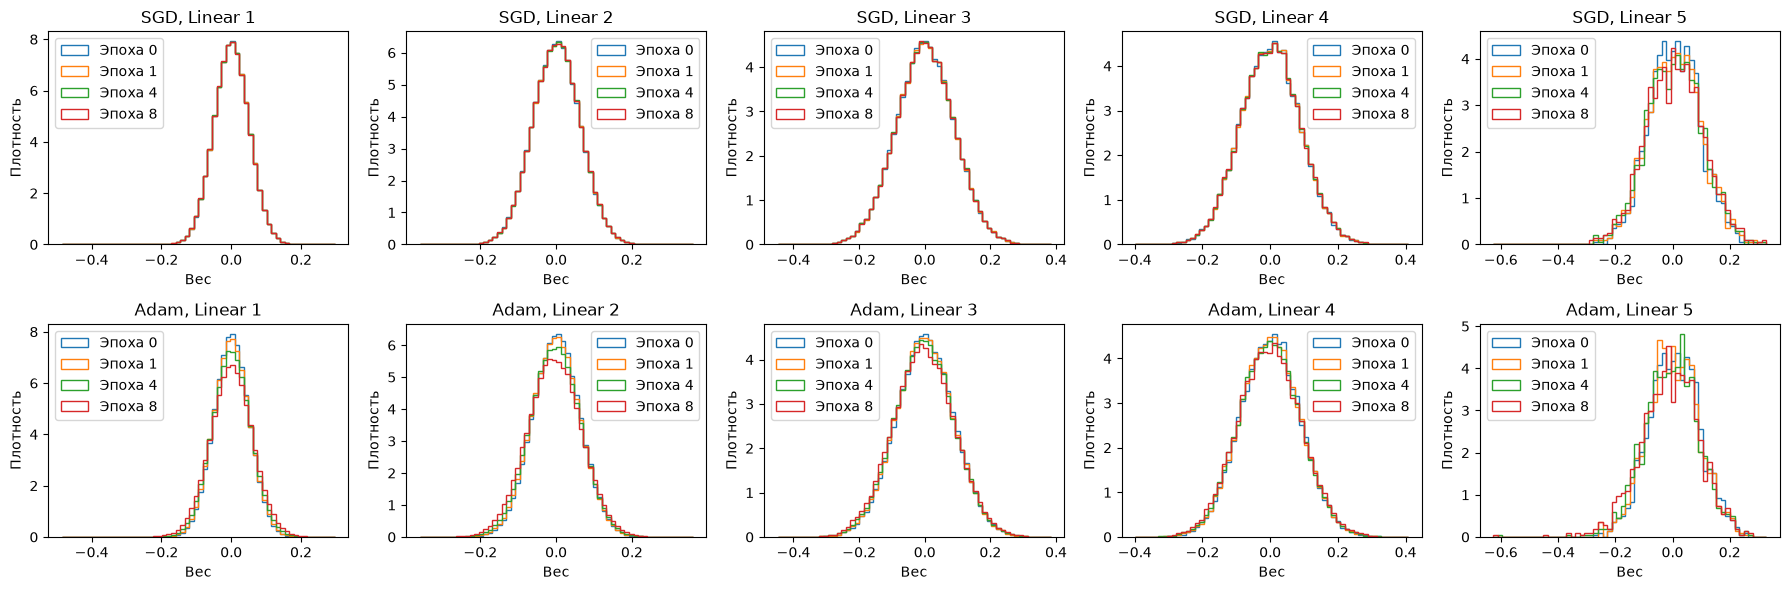

In [10]:
fig, axes = plt.subplots(2, 5, figsize=(18, 6))
for layer in range(5):
    values = torch.cat([history["weights"][epoch][layer] for history in histories.values() for epoch in [0, 1, 4, 8]])
    bins = torch.linspace(values.min(), values.max(), 61).numpy()
    for row, (name, history) in enumerate(histories.items()):
        for epoch in [0, 1, 4, 8]:
            axes[row, layer].hist(history["weights"][epoch][layer].numpy(), bins=bins, density=True, histtype="step", label=f"Эпоха {epoch}")
        axes[row, layer].set_title(f"{name}, Linear {layer + 1}")
        axes[row, layer].set_xlabel("Вес")
        axes[row, layer].set_ylabel("Плотность")
        axes[row, layer].legend()
plt.tight_layout()
plt.show()

## Выводы

Все 8 тестов пройдены. На нескольких шагах параметры и моменты совпадают с torch.optim.Adam с точностью 1e-12.

Результаты после 8 эпох:

| Оптимизатор | Train loss | Test loss | Test accuracy | Средняя норма градиента |
|---|---:|---:|---:|---:|
| SGD | 0.3486 | 0.4004 | 85.47% | 2.1379 |
| Adam | 0.2119 | 0.3255 | 88.49% | 0.9198 |

Adam сходится быстрее по числу эпох: уже после второй эпохи accuracy равна 87.12%, выше результата SGD после восьмой эпохи. Итоговая разница составляет 3.02 процентного пункта.

Средняя норма градиента у Adam снижается с 2.0756 до 0.9198, у SGD — с 2.3205 до 2.1379. Это норма исходного градиента, а не размер шага оптимизатора.

При SGD распределения весов скрытых слоёв меняются мало. При Adam они расширяются заметнее, особенно в первом слое; у выходного слоя появляются более выраженные хвосты. Резкого роста масштаба весов на графиках нет.

У Adam разрыв между train loss и test loss больше. На восьмой эпохе accuracy немного ниже, чем на седьмой, хотя train loss продолжает снижаться.

Сравнение относится к выбранным learning rate и одному seed; подбор гиперпараметров не проводился.
